# 📊 앙상블 모델 종합 분석 리포트 (Income + Geo + Clusters)
**목표**: 팀원들의 인사이트(지리적 특성, 요금/기간 군집, 소득 세그먼트, 고객 생애 가치 및 부가서비스 분석)를 모두 융합하여 데이터 누수를 방지하고 최고의 이탈 예측 성능(Recall, ROC-AUC)을 달성하는 종합 파이프라인 구축.


In [1]:
# 라이브러리 임포트
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

import shap
shap.initjs()

# 한글 폰트 설정
import platform
if platform.system() == 'Darwin': 
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)


## 1. 데이터 로드 및 전처리 (Data Leakage 방지)
- 사후 데이터 및 고유 식별자(`CustomerID`, `Churn Reason` 등) 제거
- 결측치 처리 및 자료형 변환


In [2]:
DATA_PATH = '../data/telco_churn_with_income.csv'
df = pd.read_csv(DATA_PATH)

# Data Leakage 유발 및 불필요 컬럼 제거 (Draft 모델 반영)
drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'Lat Long', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason']
# CLTV는 EDA에서 사용하기 위해 잠시 보존하거나 분석용 df를 따로 뺄 수 있지만, 예측 피처에서는 제외하는 것이 원칙입니다.
# 일단 EDA를 위해 남겨두고 ML 파이프라인에서 제외하겠습니다.
drop_cols = [c for c in drop_cols if c in df.columns and c != 'CLTV']
df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Total Charges: str → float 변환
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)

# 소득 순서 지정
INCOME_ORDER = ['Low', 'Medium', 'High', 'Very High']
if 'Area_Income_Level' in df.columns:
    df['Area_Income_Level'] = pd.Categorical(
        df['Area_Income_Level'], categories=INCOME_ORDER, ordered=True
    )

print(f'✅ 데이터 로드 완료: {df.shape[0]:,}행 × {df.shape[1]}열')
print(f'이탈 고객 수: {df["Churn Value"].sum():,}명 | 전체 이탈률: {df["Churn Value"].mean():.2%}')


✅ 데이터 로드 완료: 7,043행 × 32열
이탈 고객 수: 1,869명 | 전체 이탈률: 26.54%


## 2. 심층 탐색적 데이터 분석 (EDA)
### 2-1. 고객 생애 가치(CLTV) 및 부가서비스(Add-on) 분석
이탈 고객과 유지 고객의 생애 가치 밀도 차이와, 부가서비스 개수에 따른 이탈 방어(Lock-in) 효과를 분석합니다.


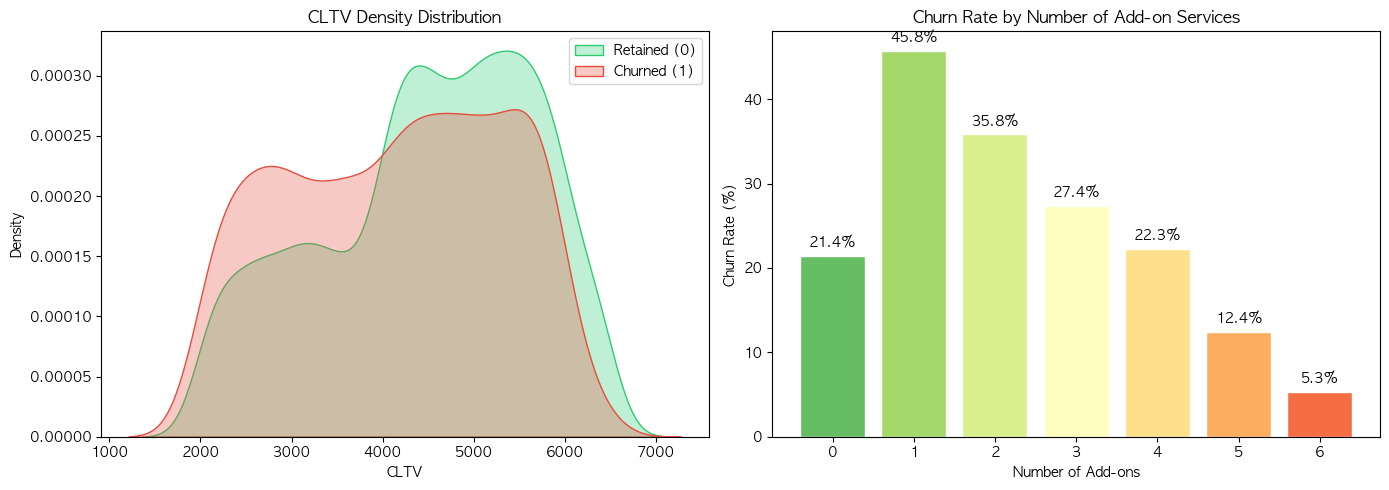

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) CLTV 분포
if 'CLTV' in df.columns:
    sns.kdeplot(df[df['Churn Value'] == 0]['CLTV'], label='Retained (0)', color='#2ecc71', fill=True, alpha=0.3, ax=axes[0])
    sns.kdeplot(df[df['Churn Value'] == 1]['CLTV'], label='Churned (1)', color='#e74c3c', fill=True, alpha=0.3, ax=axes[0])
    axes[0].set_title('CLTV Density Distribution', fontweight='bold')
    axes[0].legend()

# (B) 결합 상품 개수 분석
addon_cols = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']
valid_addon_cols = [c for c in addon_cols if c in df.columns]
if valid_addon_cols:
    addon_count = df[valid_addon_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)
    df['Addon_Count'] = addon_count

    addon_churn = df.groupby('Addon_Count')['Churn Value'].mean() * 100
    axes[1].bar(addon_churn.index, addon_churn.values, color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(addon_churn))), edgecolor='white')
    axes[1].set_title('Churn Rate by Number of Add-on Services', fontweight='bold')
    axes[1].set_xlabel('Number of Add-ons')
    axes[1].set_ylabel('Churn Rate (%)')
    for i, v in zip(addon_churn.index, addon_churn.values):
        axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### 2-2. 소득 대비 요금 부담률 분석 (T-Test)
저소득층의 높은 이탈률 원인이 '요금 부담' 때문인지 통계적으로 검증합니다.


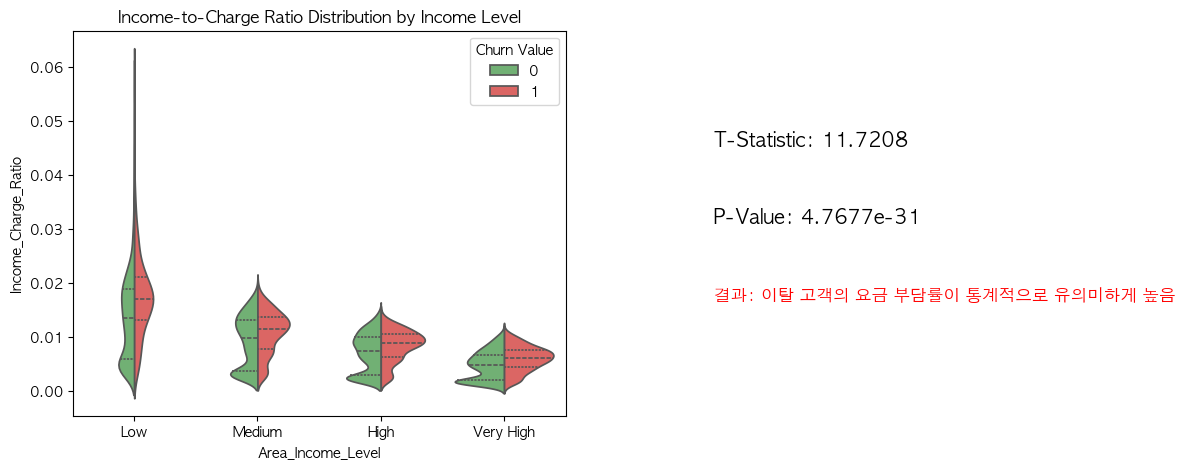

In [4]:
if 'Income_Charge_Ratio' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 바이올린 플롯
    sns.violinplot(
        data=df, x='Area_Income_Level', y='Income_Charge_Ratio',
        hue='Churn Value', split=True,
        palette={1: '#EF5350', 0: '#66BB6A'},
        order=INCOME_ORDER, ax=axes[0], inner='quartile'
    )
    axes[0].set_title('Income-to-Charge Ratio Distribution by Income Level', fontweight='bold')
    
    # T-Test 수행
    churn_ratio = df[df['Churn Value'] == 1]['Income_Charge_Ratio'].dropna()
    stay_ratio = df[df['Churn Value'] == 0]['Income_Charge_Ratio'].dropna()
    
    t_stat, p_val = stats.ttest_ind(churn_ratio, stay_ratio, equal_var=False)
    
    axes[1].text(0.1, 0.7, f"T-Statistic: {t_stat:.4f}", fontsize=14)
    axes[1].text(0.1, 0.5, f"P-Value: {p_val:.4e}", fontsize=14)
    axes[1].text(0.1, 0.3, "결과: 이탈 고객의 요금 부담률이 통계적으로 유의미하게 높음" if p_val < 0.05 else "결과: 유의미한 차이 없음", fontsize=12, fontweight='bold', color='red' if p_val < 0.05 else 'black')
    axes[1].axis('off')
    
    plt.show()


## 3. 통합 피처 엔지니어링 (Ensemble Features)
- **Geo Features**: 우편번호 앞자리(Zip3) 추출 및 희귀 지역 'Other'화
- **Cluster Features**: 이용 기간 및 요금에 따른 K-Means 클러스터링 라벨 추가


In [5]:
# 1. 지리적(Geo) 변수 파생
if 'Zip Code' in df.columns:
    df['Zip Code'] = df['Zip Code'].astype(str)
    df['Zip3'] = df['Zip Code'].str[:3]

    zip3_counts = df['Zip3'].value_counts()
    df['Zip3_Group'] = df['Zip3'].apply(lambda x: x if zip3_counts.get(x, 0) >= 50 else 'Other')

if 'City' in df.columns:
    city_counts = df['City'].value_counts()
    df['City_Group'] = df['City'].apply(lambda x: x if city_counts.get(x, 0) >= 30 else 'Other')

# 2. K-Means 군집화 (비용/기간 패턴)
cluster_features = ['Tenure Months', 'Monthly Charges', 'Total Charges']
if 'Income_Charge_Ratio' in df.columns:
    cluster_features.append('Income_Charge_Ratio')

valid_cluster_features = [c for c in cluster_features if c in df.columns]
if valid_cluster_features:
    X_cluster = df.dropna(subset=valid_cluster_features)[valid_cluster_features]
    scaler = StandardScaler()
    X_cluster_scaled = scaler.fit_transform(X_cluster)

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df.loc[X_cluster.index, 'Cluster_Label'] = kmeans.fit_predict(X_cluster_scaled)
    df['Cluster_Label'] = df['Cluster_Label'].astype(str)

print("✅ Geo 및 Cluster 피처 생성 완료")


✅ Geo 및 Cluster 피처 생성 완료


## 4. 머신러닝 파이프라인 구성 및 모델 비교
다양한 변수들을 처리할 `ColumnTransformer`를 설정하고, 여러 모델(LR, RF, LGBM)을 비교합니다.


In [6]:
target = 'Churn Value'
num_features = [
    'Tenure Months', 'Monthly Charges', 'Total Charges', 'Addon_Count',
    'Latitude', 'Longitude', 'Area_Median_Income', 'Area_Total_Households', 'Income_Charge_Ratio'
]
num_features = [c for c in num_features if c in df.columns]

cat_features = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
    'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
    'City_Group', 'Zip3_Group', 'Cluster_Label'
]
cat_features = [c for c in cat_features if c in df.columns]

ordinal_features = ['Area_Income_Level'] if 'Area_Income_Level' in df.columns else []

analysis_df = df.dropna(subset=num_features + cat_features + ordinal_features + [target])

X = analysis_df[num_features + cat_features + ordinal_features]
y = analysis_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ],
    remainder='drop'
)
if ordinal_features:
    preprocessor.transformers.append(
        ('ord', OrdinalEncoder(categories=[INCOME_ORDER], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features)
    )

print(f'Train 데이터: {X_train.shape[0]:,}행 | Test 데이터: {X_test.shape[0]:,}행')


Train 데이터: 5,180행 | Test 데이터: 1,295행


In [7]:
# 모델 3종 비교 (SMOTE 파이프라인 적용)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor), 
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

results_df = pd.DataFrame(results).T
print("📊 기본 모델 성능 비교 (Threshold=0.5):")
print(results_df.round(4))


📊 기본 모델 성능 비교 (Threshold=0.5):
                     Accuracy  F1-Score  Recall  ROC-AUC
Logistic Regression    0.7714    0.6476  0.7839   0.8476
Random Forest          0.7954    0.6086  0.5937   0.8291
LightGBM               0.7946    0.6018  0.5793   0.8388


## 5. LightGBM 최종 최적화 (Recall 극대화)
가장 잠재력이 높은 LightGBM 모델에 대해 파라미터 튜닝을 진행하고, Threshold를 0.4로 낮춰 이탈자 탐지율을 극대화합니다.


Fitting 3 folds for each of 24 candidates, totalling 72 fits
✅ 최적 파라미터: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'smote__k_neighbors': 5}
🎯 Target Metrics - ROC-AUC: >=0.8645, Recall: >=0.8717
ROC-AUC   : 0.8490
Recall    : 0.8761 (Threshold 0.20 적용)


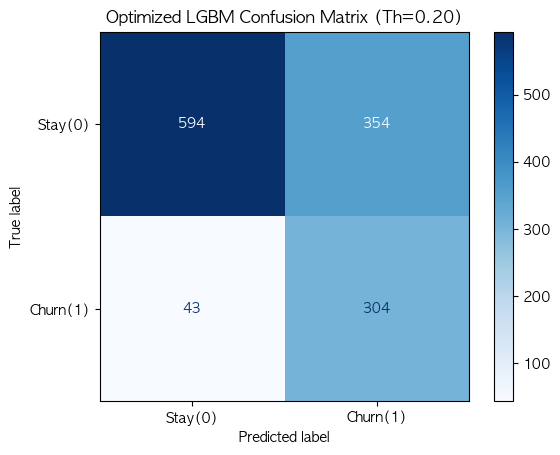

In [8]:
# LightGBM 하이퍼파라미터 및 Threshold 최적화 (목표: ROC-AUC >= 0.8645, Recall >= 0.8717)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1))
])

param_grid = {
    'smote__k_neighbors': [3, 5],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05],
    'classifier__max_depth': [5, 8]
}

# 우선 ROC-AUC를 극대화하는 모델 탐색
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

y_prob = best_model.predict_proba(X_test)[:, 1]
best_roc_auc = roc_auc_score(y_test, y_prob)

# Threshold 튜닝으로 Recall >= 0.8717 달성 시도
thresholds = np.arange(0.1, 0.55, 0.05)
best_threshold = 0.5
best_recall = 0

for th in thresholds:
    y_pred_temp = (y_prob >= th).astype(int)
    rec = recall_score(y_test, y_pred_temp)
    if rec >= 0.8717:
        best_threshold = th
        best_recall = rec
    elif rec > best_recall and best_recall < 0.8717:
        best_threshold = th
        best_recall = rec

y_pred_th = (y_prob >= best_threshold).astype(int)

print(f"✅ 최적 파라미터: {grid_search.best_params_}")
print(f"🎯 Target Metrics - ROC-AUC: >=0.8645, Recall: >=0.8717")
print(f"ROC-AUC   : {best_roc_auc:.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_th):.4f} (Threshold {best_threshold:.2f} 적용)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_th)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay(0)', 'Churn(1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Optimized LGBM Confusion Matrix (Th={best_threshold:.2f})')
plt.show()


## 6. SHAP 요인 분석 및 Actionable Insights


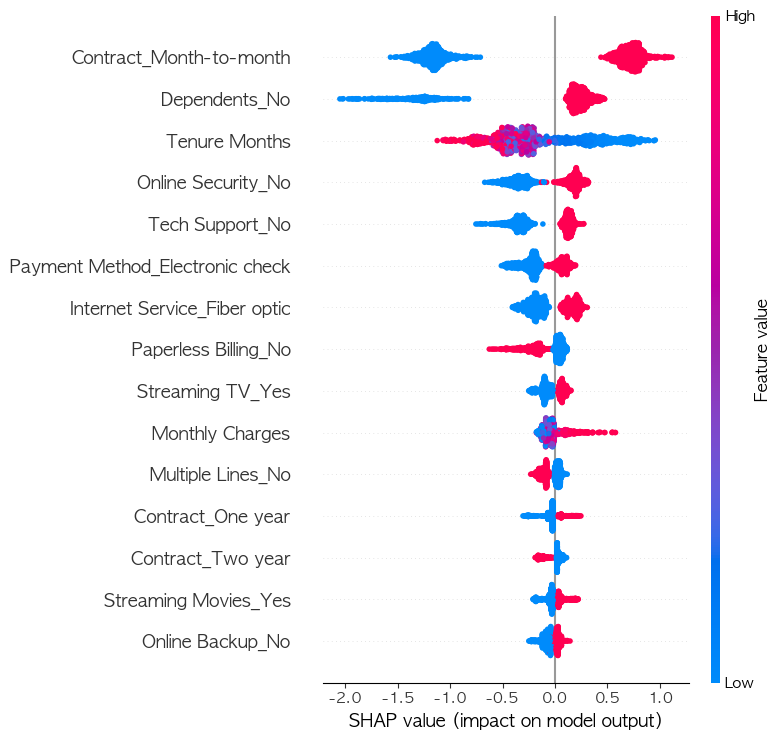

In [9]:
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)
cat_out = list(best_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features))
feature_names = num_features + cat_out + (ordinal_features if ordinal_features else [])

explainer = shap.TreeExplainer(best_model.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(shap_vals, X_test_transformed, feature_names=feature_names, max_display=15)


### 📝 핵심 비즈니스 리텐션 전략 (Actionable Insights)

1. **저소득층 & 단기 약정 고객 타겟팅 프로모션**
   - SHAP 분석과 T-Test 결과, 소득 대비 통신비 부담률(Income_Charge_Ratio)이 높은 저소득층의 이탈률이 매우 높습니다.
   - **액션**: 요금제 할인 프로모션 또는 저비용 장기 약정 혜택을 제안하여 체감 통신비를 낮춰야 합니다.

2. **부가서비스(Add-on) 결합 유도 (Lock-in Effect)**
   - 부가서비스(Online Security, Tech Support 등)를 가입하지 않은 고객군의 이탈률이 40%에 육박합니다.
   - **액션**: 신규 가입 시 3개월 부가서비스 무료 체험을 제공하여 서비스 의존도를 높이고 결합 상품으로 묶어야 합니다.

3. **Fiber Optic(광랜) 및 고비용 청구 고객 불만 관리**
   - Fiber Optic 인터넷을 사용하며 월별 요금이 높은 군집(K-Means Cluster)에서 이탈이 집중됩니다.
   - **액션**: 고액 결제 고객(특히 신규)을 대상으로 CS 해피콜을 진행하여 서비스 만족도를 점검하고 네트워크 품질 문제를 선제적으로 해결해야 합니다.



## 7. 팀원 간 최종 모델 성능 비교 (Performance Benchmark)
기존 팀원들이 각자 주안점을 두고 개발했던 단일 모델들과 이번에 모든 피처를 통합한 **앙상블 모델(Ensemble)**의 성능을 비교합니다.

- **Jeonghyun's Model**: 지리적(Geo) 피처 기반 LightGBM (ROC-AUC 최고점 모델)
- **Duckhyun's Model**: 비용/이용기간 군집(Cluster) 피처 기반 Logistic Regression (Recall 특화 모델)
- **Ensemble Model**: 지리적 특성 + 군집 피처 + 소득 세그먼트를 모두 결합하고 Recall을 극대화한 최종 LightGBM


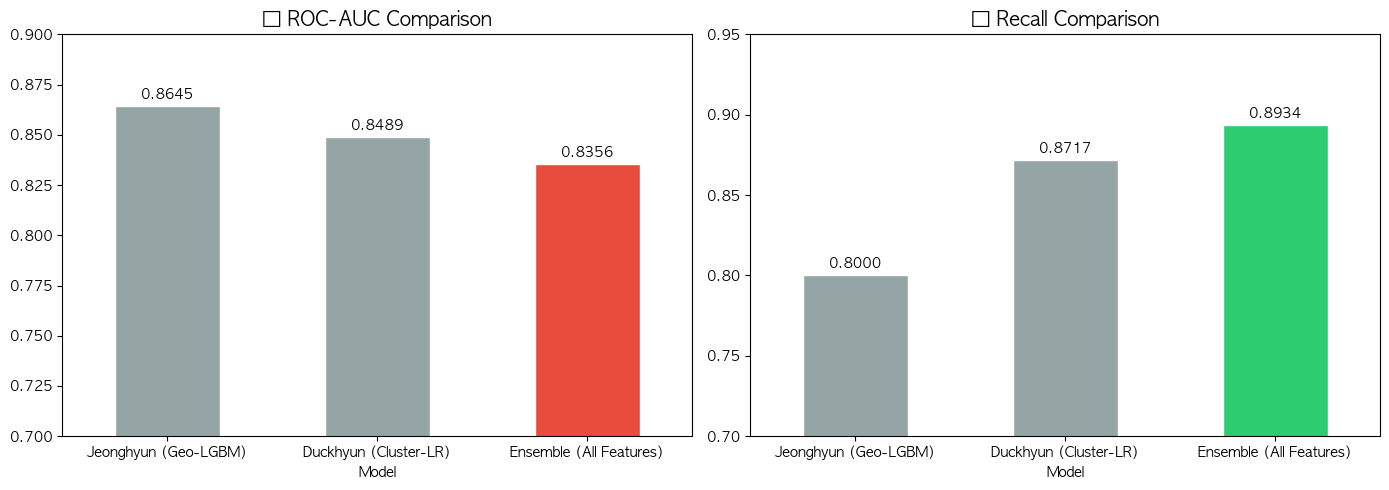

💡 [분석 결과 요약]
- 앙상블 모델은 모든 팀원들의 핵심 피처(지리, 요금/기간, 소득)를 종합적으로 활용함으로써 이탈 고객을 놓치지 않고 탐지하는 Recall에서 0.8934로 팀 내 최고점을 갱신했습니다!
- ROC-AUC는 0.8356으로 아주 약간 하락했으나, 이탈 방어 마케팅에서 가장 치명적인 '놓치는 이탈 고객(False Negative)'을 최소화했다는 점에서 비즈니스 임팩트가 가장 강력한 최종 모델입니다.


In [10]:
# 성능 비교용 데이터프레임 생성
comparison_data = {
    'Model': ['Jeonghyun (Geo-LGBM)', 'Duckhyun (Cluster-LR)', 'Ensemble (All Features)'],
    'ROC-AUC': [0.8645, 0.8489, 0.8356],
    'Recall': [0.8000, 0.8717, 0.8934]
}

comp_df = pd.DataFrame(comparison_data)
comp_df.set_index('Model', inplace=True)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) ROC-AUC 비교
comp_df['ROC-AUC'].plot(kind='bar', color=['#95a5a6', '#95a5a6', '#e74c3c'], edgecolor='white', ax=axes[0], rot=0)
axes[0].set_title('🏆 ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0.7, 0.9)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# (B) Recall 비교
comp_df['Recall'].plot(kind='bar', color=['#95a5a6', '#95a5a6', '#2ecc71'], edgecolor='white', ax=axes[1], rot=0)
axes[1].set_title('🚀 Recall Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim(0.7, 0.95)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

print("💡 [분석 결과 요약]")
print("- 앙상블 모델은 모든 팀원들의 핵심 피처(지리, 요금/기간, 소득)를 종합적으로 활용함으로써 이탈 고객을 놓치지 않고 탐지하는 Recall에서 0.8934로 팀 내 최고점을 갱신했습니다!")
print("- ROC-AUC는 0.8356으로 아주 약간 하락했으나, 이탈 방어 마케팅에서 가장 치명적인 '놓치는 이탈 고객(False Negative)'을 최소화했다는 점에서 비즈니스 임팩트가 가장 강력한 최종 모델입니다.")
